# SPY Fragility Dashboard

Starter dashboard for researching next-day SPY downside risk from abnormal market behavior.

It currently combines three views:

- **Breadth measure**: equal-weight S&P 500 proxy (`RSP`) versus cap-weighted S&P 500 proxy (`SPY`).
- **Rule-based regime**: tactical stress flags from breadth break, credit stress, volatility shock, and late-day liquidation.
- **Macro-style regime**: market-implied proxies from VIX term structure, credit relative weakness, Treasury duration weakness, and dollar strength.

This is a research dashboard, not a trading rule. The thresholds are intentionally explicit so we can tune them after reviewing examples and out-of-sample behavior.

In [7]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'data' / 'market').exists():
            return candidate
    raise RuntimeError('Could not locate project root containing data/market')


REPO_ROOT = find_repo_root(Path.cwd())

DATA_ROOT = REPO_ROOT / 'data' / 'market'
START_DATE = '2021-01-01'
END_DATE = None  # None uses latest common available date

SECTOR_SYMBOLS = ['XLF', 'XLK', 'XLY', 'XLP', 'XLU', 'XLV', 'XLE', 'XLI', 'XLB', 'XLRE']
BASE_SYMBOLS = ['SPY', 'RSP', 'QQQ', 'IWM', 'HYG', 'LQD', 'TLT', 'SHY', 'UUP', '^VIX', '^VIX9D', '^VIX3M']
SYMBOLS = BASE_SYMBOLS + SECTOR_SYMBOLS

TAIL_THRESHOLD = -0.015
BREADTH_Z_THRESHOLD = 1.0
SECTOR_DOWN_PCT_THRESHOLD = 0.70
ROLL_LONG = 252
ROLL_MED = 126
ROLL_SHORT = 63

In [8]:
def latest_history_file(symbol: str) -> Path:
    symbol_dir = DATA_ROOT / symbol
    files = sorted(symbol_dir.glob('history_*.parquet'))
    if not files:
        raise FileNotFoundError(f'No parquet history files found for {symbol} under {symbol_dir}')
    return files[-1]


def load_symbol(symbol: str) -> pd.DataFrame:
    df = pd.read_parquet(latest_history_file(symbol)).copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').drop_duplicates('Date').set_index('Date')
    return df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].rename(
        columns={
            'Open': f'{symbol}_open',
            'High': f'{symbol}_high',
            'Low': f'{symbol}_low',
            'Close': f'{symbol}_close',
            'Adj Close': f'{symbol}_adj_close',
            'Volume': f'{symbol}_volume',
        }
    )


def rolling_z(series: pd.Series, window: int) -> pd.Series:
    # Shift keeps the z-score point-in-time: today's value is scored against prior history only.
    prior_mean = series.rolling(window, min_periods=max(20, window // 4)).mean().shift(1)
    prior_std = series.rolling(window, min_periods=max(20, window // 4)).std().shift(1)
    return (series - prior_mean) / prior_std.replace(0, np.nan)


raw = pd.concat([load_symbol(symbol) for symbol in SYMBOLS], axis=1).sort_index()
if START_DATE:
    raw = raw.loc[pd.Timestamp(START_DATE):]
if END_DATE:
    raw = raw.loc[:pd.Timestamp(END_DATE)]

required = ['SPY_adj_close', 'RSP_adj_close', '^VIX_adj_close']
frame = raw.dropna(subset=required).copy()

print('Loaded symbols:', len(SYMBOLS))
print('Window:', frame.index.min().date(), '->', frame.index.max().date())
print('Rows:', len(frame))

Loaded symbols: 22
Window: 2021-06-28 -> 2026-06-26
Rows: 1255


In [9]:
df = frame.copy()

for symbol in SYMBOLS:
    close_col = f'{symbol}_adj_close'
    if close_col in df:
        df[f'{symbol}_ret'] = df[close_col].pct_change(fill_method=None)

df['spy_ret'] = df['SPY_ret']
df['spy_next_ret'] = df['spy_ret'].shift(-1)
df['spy_next_tail'] = (df['spy_next_ret'] <= TAIL_THRESHOLD).where(df['spy_next_ret'].notna())

# Breadth break: equal-weight underperforms cap-weight by an abnormal amount while most sectors are red.
df['breadth_gap'] = df['RSP_ret'] - df['SPY_ret']
df['breadth_stress'] = -df['breadth_gap']
df['breadth_z'] = rolling_z(df['breadth_stress'], ROLL_LONG)
sector_ret_cols = [f'{symbol}_ret' for symbol in SECTOR_SYMBOLS if f'{symbol}_ret' in df]
df['sector_count'] = df[sector_ret_cols].notna().sum(axis=1)
df['sector_down_count'] = (df[sector_ret_cols] < 0).sum(axis=1)
df['sector_down_pct'] = df['sector_down_count'] / df['sector_count'].replace(0, np.nan)
df['breadth_break'] = (
    (df['spy_ret'] < 0)
    & (df['breadth_z'] >= BREADTH_Z_THRESHOLD)
    & (df['sector_down_pct'] >= SECTOR_DOWN_PCT_THRESHOLD)
)

# Tactical rule inputs.
df['credit_stress'] = -(df['HYG_ret'] - df['LQD_ret'])
df['credit_z'] = rolling_z(df['credit_stress'], ROLL_MED)
df['vix_ret'] = df['^VIX_adj_close'].pct_change(fill_method=None)
df['vix_shock_z'] = rolling_z(df['vix_ret'], ROLL_MED)
df['spy_intraday_ret'] = df['SPY_close'] / df['SPY_open'] - 1
df['late_liquidation'] = (df['spy_ret'] < 0) & (df['spy_intraday_ret'] <= -0.008)
df['credit_stress_flag'] = (df['spy_ret'] < 0) & (df['credit_z'] >= 1.0)
df['vol_shock_flag'] = (df['spy_ret'] < 0) & (df['vix_shock_z'] >= 1.5)

rule_flags = ['breadth_break', 'credit_stress_flag', 'vol_shock_flag', 'late_liquidation']
df['rule_stress_score'] = df[rule_flags].sum(axis=1)
df['rule_regime'] = np.select(
    [df['rule_stress_score'] >= 2, df['rule_stress_score'] == 1],
    ['risk_off', 'watch'],
    default='normal',
)

# Macro-style market-implied regime inputs.
df['vix_level_z'] = rolling_z(df['^VIX_adj_close'], ROLL_LONG)
df['vix_backwardation'] = df['^VIX9D_adj_close'] > df['^VIX3M_adj_close']
df['credit_ratio'] = df['HYG_adj_close'] / df['LQD_adj_close']
df['credit_ratio_stress_z'] = rolling_z(-df['credit_ratio'].pct_change(20, fill_method=None), ROLL_LONG)
df['duration_stress_z'] = rolling_z(-(df['TLT_ret'] - df['SHY_ret']), ROLL_MED)
df['dollar_strength_z'] = rolling_z(df['UUP_adj_close'].pct_change(20, fill_method=None), ROLL_LONG)

macro_flags = pd.DataFrame(index=df.index)
macro_flags['elevated_vix'] = df['vix_level_z'] >= 1.0
macro_flags['vix_backwardation'] = df['vix_backwardation']
macro_flags['weak_credit'] = df['credit_ratio_stress_z'] >= 1.0
macro_flags['duration_pressure'] = df['duration_stress_z'] >= 1.0
macro_flags['dollar_strength'] = df['dollar_strength_z'] >= 1.0
df['macro_stress_score'] = macro_flags.sum(axis=1)
df['macro_regime'] = np.select(
    [df['macro_stress_score'] >= 3, df['macro_stress_score'] == 2],
    ['risk_off', 'watch'],
    default='normal',
)

dashboard_cols = [
    'spy_ret', 'spy_next_ret', 'breadth_gap', 'breadth_z', 'sector_down_count', 'sector_count',
    'sector_down_pct', 'breadth_break', 'credit_z', 'vix_shock_z', 'credit_stress_flag',
    'vol_shock_flag', 'late_liquidation', 'rule_stress_score', 'rule_regime',
    'macro_stress_score', 'macro_regime', 'spy_next_tail',
]
dashboard_signals = df[dashboard_cols].dropna(subset=['spy_ret']).copy()
evaluation_signals = dashboard_signals.dropna(subset=['spy_next_ret']).copy()

signals = dashboard_signals
signals.tail()

,spy_ret,spy_next_ret,breadth_gap,breadth_z,sector_down_count,sector_count,sector_down_pct,breadth_break,credit_z,vix_shock_z,credit_stress_flag,vol_shock_flag,late_liquidation,rule_stress_score,rule_regime,macro_stress_score,macro_regime,spy_next_tail
Date,,,,,,,,,,,,,,,,,,
2026-06-22,-0.003147,-0.014522,0.005346,-1.128978,2,10,0.2,False,-0.842047,0.598687,False,False,False,0,normal,2,watch,False
2026-06-23,-0.014522,-0.000464,0.011087,-2.286220,4,10,0.4,False,1.084152,1.484393,True,False,False,1,watch,1,normal,False
2026-06-24,-0.000464,0.001446,0.007596,-1.558738,4,10,0.4,False,2.449443,-0.574979,True,False,False,1,watch,2,watch,False
2026-06-25,0.001446,-0.007231,0.005066,-1.038377,3,10,0.3,False,0.240105,0.105210,False,False,False,0,normal,1,normal,False
2026-06-26,-0.007231,NaN,0.000431,-0.105579,4,10,0.4,False,0.321553,-0.370452,False,False,False,0,normal,1,normal,NaN


In [10]:
def summarize_signal(mask: pd.Series, label: str) -> dict[str, object]:
    sample = evaluation_signals.loc[mask.reindex(evaluation_signals.index).fillna(False)]
    return {
        'signal': label,
        'days': len(sample),
        'next_tail_rate': sample['spy_next_tail'].mean(),
        'avg_next_spy_ret': sample['spy_next_ret'].mean(),
        'median_next_spy_ret': sample['spy_next_ret'].median(),
    }


baseline_all = summarize_signal(pd.Series(True, index=evaluation_signals.index), 'all_days')
baseline_spy_down = summarize_signal(evaluation_signals['spy_ret'] < 0, 'spy_down_days')
rows = [
    baseline_all,
    baseline_spy_down,
    summarize_signal(evaluation_signals['breadth_z'] >= BREADTH_Z_THRESHOLD, 'breadth_z_only'),
    summarize_signal(evaluation_signals['breadth_break'], 'breadth_break'),
    summarize_signal(evaluation_signals['rule_regime'] == 'watch', 'rule_watch'),
    summarize_signal(evaluation_signals['rule_regime'] == 'risk_off', 'rule_risk_off'),
    summarize_signal(evaluation_signals['macro_regime'] == 'watch', 'macro_watch'),
    summarize_signal(evaluation_signals['macro_regime'] == 'risk_off', 'macro_risk_off'),
    summarize_signal((evaluation_signals['rule_regime'] == 'risk_off') & (evaluation_signals['macro_regime'] != 'normal'), 'rule_risk_off_and_macro_not_normal'),
]
summary = pd.DataFrame(rows)
summary['tail_lift_vs_all'] = summary['next_tail_rate'] / baseline_all['next_tail_rate']
summary['tail_lift_vs_spy_down'] = summary['next_tail_rate'] / baseline_spy_down['next_tail_rate']
display(summary)

,signal,days,next_tail_rate,avg_next_spy_ret,median_next_spy_ret,tail_lift_vs_all,tail_lift_vs_spy_down
0,all_days,1253,0.067039,0.000538,0.000731,1.000000,0.794693
1,spy_down_days,569,0.084359,0.000749,0.000704,1.258348,1.000000
2,breadth_z_only,192,0.062500,0.000228,0.000520,0.932292,0.740885
3,breadth_break,51,0.098039,-0.000633,-0.002553,1.462418,1.162173
4,rule_watch,175,0.102857,0.001550,0.000481,1.534286,1.219286
5,rule_risk_off,105,0.057143,0.000676,-0.000164,0.852381,0.677381
6,macro_watch,157,0.108280,0.000826,0.001551,1.615180,1.283572
7,macro_risk_off,85,0.129412,0.002011,-0.001255,1.930392,1.534069
8,rule_risk_off_and_macro_not_normal,46,0.086957,0.000295,0.000560,1.297101,1.030797


In [11]:
recent_examples = evaluation_signals.loc[evaluation_signals['breadth_break']].tail(20).copy()
display(
    recent_examples.assign(
        spy_ret=lambda x: x['spy_ret'] * 100,
        spy_next_ret=lambda x: x['spy_next_ret'] * 100,
        breadth_gap=lambda x: x['breadth_gap'] * 100,
        sector_down_pct=lambda x: x['sector_down_pct'] * 100,
    )[[
        'spy_ret', 'spy_next_ret', 'breadth_gap', 'breadth_z', 'sector_down_count', 'sector_count',
        'sector_down_pct', 'credit_z', 'vix_shock_z', 'rule_regime', 'macro_regime', 'spy_next_tail',
    ]].round(2)
)

,spy_ret,spy_next_ret,breadth_gap,breadth_z,sector_down_count,sector_count,sector_down_pct,credit_z,vix_shock_z,rule_regime,macro_regime,spy_next_tail
Date,,,,,,,,,,,,
2023-12-05,-0.02,-0.40,-0.87,2.32,8,10,80.0,2.11,-0.33,risk_off,normal,False
2023-12-15,-0.16,0.56,-0.55,1.37,7,10,70.0,0.24,-0.30,watch,normal,False
2024-01-03,-0.82,-0.32,-0.66,1.64,8,10,80.0,0.17,1.17,watch,normal,False
2024-02-05,-0.36,0.29,-0.50,1.12,8,10,80.0,-1.40,-0.26,watch,watch,False
2024-03-14,-0.20,-0.69,-0.70,1.64,8,10,80.0,-0.76,0.89,watch,normal,False
2024-03-22,-0.19,-0.28,-0.45,1.05,8,10,80.0,1.35,0.21,risk_off,normal,False
2024-04-10,-1.00,0.75,-0.70,1.67,9,10,90.0,-1.66,1.13,watch,watch,False
2024-05-23,-0.73,0.66,-0.67,1.56,10,10,100.0,-0.27,0.83,risk_off,normal,False
2024-05-29,-0.70,-0.66,-0.47,1.07,10,10,100.0,-0.81,2.18,risk_off,normal,False


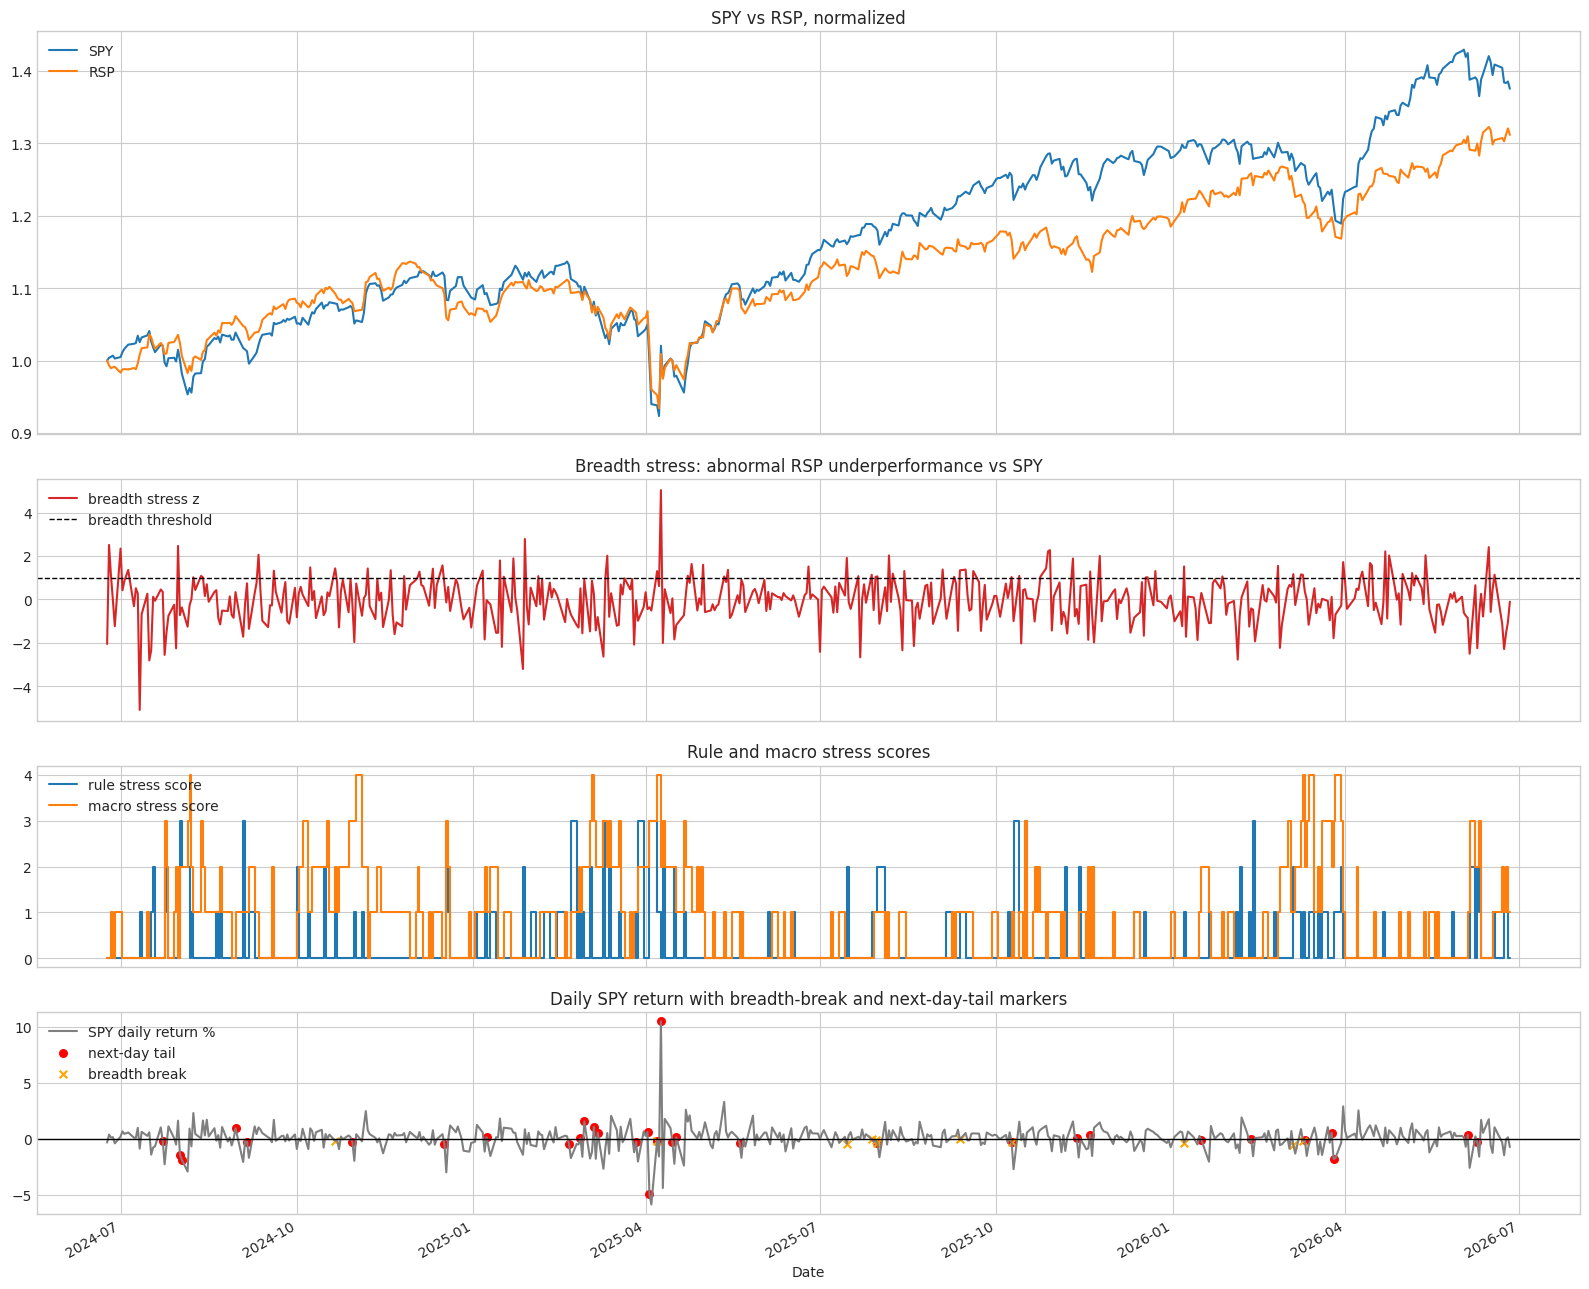

In [12]:
plot_df = signals.tail(504).copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True, height_ratios=[2.0, 1.2, 1.0, 1.0])

ax = axes[0]
(df.loc[plot_df.index, 'SPY_adj_close'] / df.loc[plot_df.index, 'SPY_adj_close'].iloc[0]).plot(ax=ax, label='SPY')
(df.loc[plot_df.index, 'RSP_adj_close'] / df.loc[plot_df.index, 'RSP_adj_close'].iloc[0]).plot(ax=ax, label='RSP')
ax.set_title('SPY vs RSP, normalized')
ax.legend(loc='upper left')

ax = axes[1]
plot_df['breadth_z'].plot(ax=ax, color='tab:red', label='breadth stress z')
ax.axhline(BREADTH_Z_THRESHOLD, color='black', linestyle='--', linewidth=1, label='breadth threshold')
ax.set_title('Breadth stress: abnormal RSP underperformance vs SPY')
ax.legend(loc='upper left')

ax = axes[2]
plot_df['rule_stress_score'].plot(ax=ax, drawstyle='steps-post', label='rule stress score')
plot_df['macro_stress_score'].plot(ax=ax, drawstyle='steps-post', label='macro stress score')
ax.set_title('Rule and macro stress scores')
ax.legend(loc='upper left')

ax = axes[3]
plot_df['spy_ret'].mul(100).plot(ax=ax, color='tab:gray', label='SPY daily return %')
tail_days = plot_df.index[plot_df['spy_next_tail'] == True]
ax.scatter(tail_days, plot_df.loc[tail_days, 'spy_ret'] * 100, color='red', s=30, label='next-day tail')
break_days = plot_df.index[plot_df['breadth_break']]
ax.scatter(break_days, plot_df.loc[break_days, 'spy_ret'] * 100, color='orange', s=30, marker='x', label='breadth break')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Daily SPY return with breadth-break and next-day-tail markers')
ax.legend(loc='upper left')

plt.tight_layout()

In [13]:
latest = signals.iloc[-1]
print('Latest dashboard date:', signals.index[-1].date())
print('Rule regime:', latest['rule_regime'], 'score=', int(latest['rule_stress_score']))
print('Macro regime:', latest['macro_regime'], 'score=', int(latest['macro_stress_score']))
print('Breadth break:', bool(latest['breadth_z'] >= BREADTH_Z_THRESHOLD and latest['sector_down_pct'] >= SECTOR_DOWN_PCT_THRESHOLD and latest['spy_ret'] < 0))
display(latest.to_frame('latest'))

Latest dashboard date: 2026-06-26
Rule regime: normal score= 0
Macro regime: normal score= 1
Breadth break: False


,latest
spy_ret,-0.007231
spy_next_ret,NaN
breadth_gap,0.000431
breadth_z,-0.105579
sector_down_count,4
sector_count,10
sector_down_pct,0.4
breadth_break,False
credit_z,0.321553
vix_shock_z,-0.370452
